In [1]:
# ============================================================
# Principal component analysis of california housing dataset
# ============================================================

# Import Libraries
from google.colab import files
import io
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ------------------------------------------
# Upload CSV file from your computer
# ------------------------------------------
print("Please upload your csv file")
uploaded = files.upload()  # Opens a file upload dialog box in Google Colab

# Read the uploaded CSV into a pandas DataFrame
df = pd.read_excel('california_housing_standardized_data.xlsx')


Please upload your csv file


Saving california_housing_standardized_data.xlsx to california_housing_standardized_data.xlsx


In [3]:
print("\nData successfully loaded! Here's what it looks like:")
# Display the first few rows to check the data
display(df.head())
df.shape


Data successfully loaded! Here's what it looks like:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-1.327835,1.052548,0.982143,-0.804819,-0.970325,-0.974429,-0.977033,2.344766,2.129631,NEAR BAY
1,-1.322844,1.043185,-0.607019,2.045890,1.348276,0.861439,1.669961,2.332238,1.314156,NEAR BAY
2,-1.332827,1.038503,1.856182,-0.535746,-0.825561,-0.820777,-0.843637,1.782699,1.258693,NEAR BAY
3,-1.337818,1.038503,1.856182,-0.624215,-0.718768,-0.766028,-0.733781,0.932968,1.165100,NEAR BAY
4,-1.337818,1.038503,1.856182,-0.462404,-0.611974,-0.759847,-0.629157,-0.012881,1.172900,NEAR BAY


(20640, 10)

In [4]:
# drop categorical column and target

df = df.drop('ocean_proximity', axis=1)
df = df.drop('median_house_value', axis=1)

print("\nYou have removed two columns!\n")
display(df.head())



You have removed two columns!



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-1.327835,1.052548,0.982143,-0.804819,-0.970325,-0.974429,-0.977033,2.344766
1,-1.322844,1.043185,-0.607019,2.045890,1.348276,0.861439,1.669961,2.332238
2,-1.332827,1.038503,1.856182,-0.535746,-0.825561,-0.820777,-0.843637,1.782699
3,-1.337818,1.038503,1.856182,-0.624215,-0.718768,-0.766028,-0.733781,0.932968
4,-1.337818,1.038503,1.856182,-0.462404,-0.611974,-0.759847,-0.629157,-0.012881


In [5]:
# ------------------------------------------
# Perform PCA
# ------------------------------------------

# Handle missing values by dropping rows with NaNs
df = df.dropna()

# create PCA model
pca_model = PCA()
pca_model.fit(df)

PCA()

In [6]:
# explained variance
explained_variance = pca_model.explained_variance_ratio_

# Cumulative variance
cum_explained_variance = np.cumsum(explained_variance)

print("\nExplained Variance Ratio:")
for i, var in enumerate(explained_variance[:10]):
    print(f"PC{i+1}: {var:.5f}")


Explained Variance Ratio:
PC1: 0.48861
PC2: 0.23832
PC3: 0.13378
PC4: 0.10286
PC5: 0.01856
PC6: 0.01017
PC7: 0.00584
PC8: 0.00185


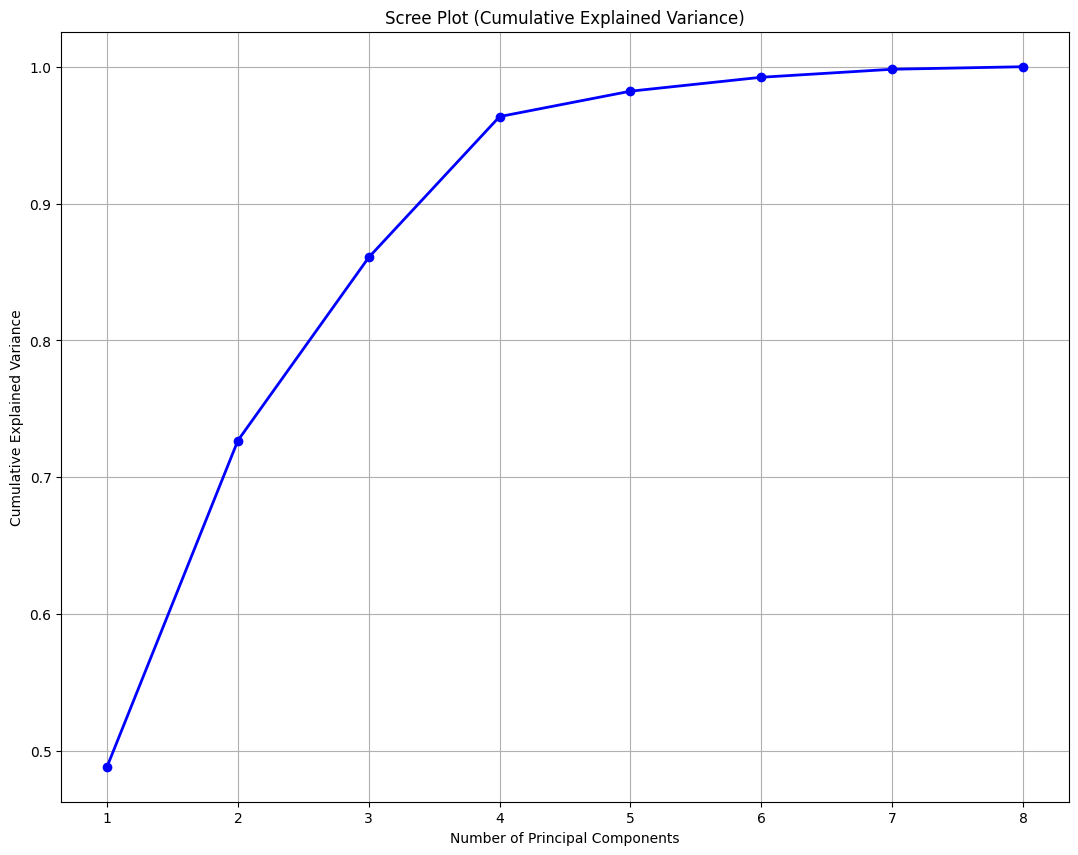

In [7]:
# ------------------------------------------
# Scree Plot
# ------------------------------------------
plt.figure(figsize=(13, 10))
plt.plot(range(1, len(explained_variance)+1), cum_explained_variance, 'bo-', linewidth=2)
plt.title('Scree Plot (Cumulative Explained Variance)')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

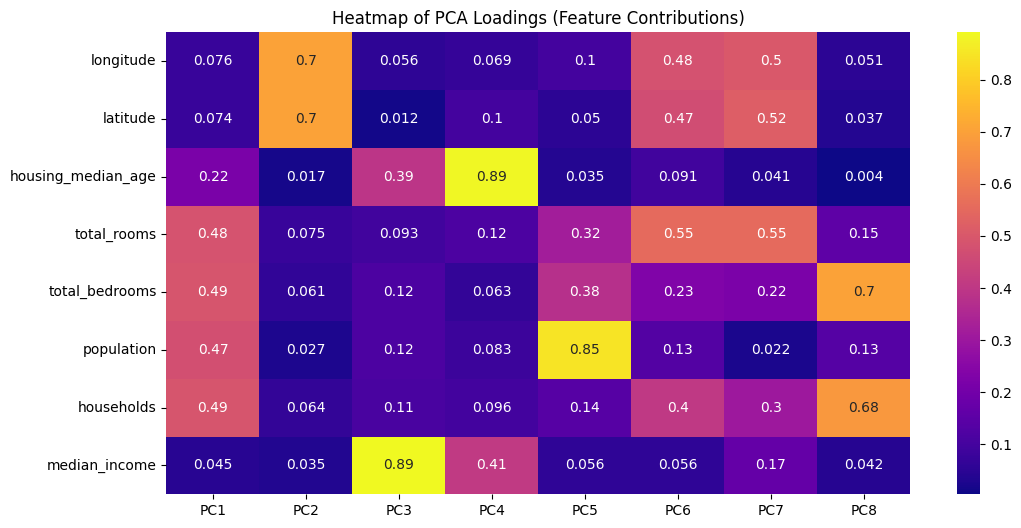

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------
# PCA LOADINGS (COMPONENT CONTRIBUTIONS)
# ------------------------------------------------
loadings = np.abs(pca_model.components_.T)
loading_df = pd.DataFrame(loadings,
                          columns=[f"PC{i+1}" for i in range(len(df.columns))],
                          index=df.columns)

# create a heatmap of loadings
plt.figure(figsize=(12, 6))
sns.heatmap(loading_df, annot=True, cmap="plasma")
plt.title("Heatmap of PCA Loadings (Feature Contributions)")
plt.show()

In [9]:
# Save to Excel file
loading_df.to_excel("pca_loadings.xlsx")

# Download from Google Colab
from google.colab import files
files.download("pca_loadings.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>